# Exploring Model Complexity

This learn-by-exploring notebook demonstrates how **model complexity** affects
training error, test error, bias, and variance.

We will use polynomial regression models with different degrees.

The main question is:

> How complex should our model be? Too complex and it overfits, too simple and it doesn't perform well. 

## 1. The basic idea

If the model is too simple, it  will not capture the patterns in
the data and will consequentially have poor performance. This is associated with **high bias**.

If the model is too complex, it can easily overfit the training data,
including its noise. This is associated with **high variance**.

Recall the three sources of error for our model:

$$
\text{Error}
 = \text{Bias}^2
+
\text{Variance}
+
\text{Irreducible Error}.
$$

For this notebook, we will use polynomial degree as our measure of model complexity. 

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split

from ipywidgets import interact, IntSlider, FloatSlider

Here we see that the *true function*, $c^{*}(x)$ we are trying to learn is cubic. 

In [2]:
def true_function(x):
    return 0.5 * x**3 - 2 * x + .4


# A large set of x-values for evaluating our models
x_true = np.linspace(-3, 3, 300)  #300 values from -3 to 3

# The true function, without noise
y_true = true_function(x_true)

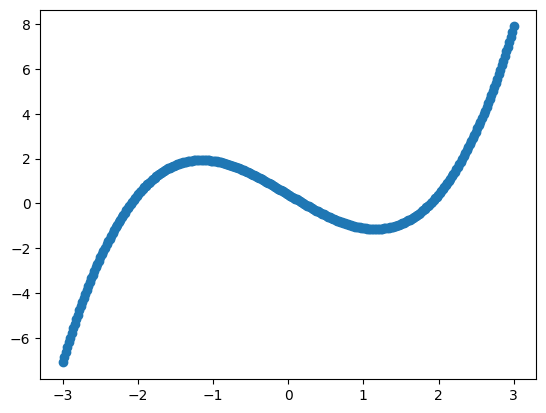

In [3]:
plt.scatter(x=x_true,y=y_true)

Our data points $(\mathbf{x},y)$ come from drawing points on the curve with some normal error attached.

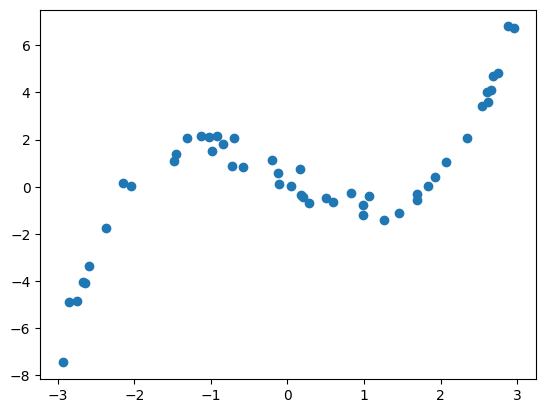

In [5]:
seed = np.random.seed = 42
def make_data(data_size=50, noise=.5):
    """
    Generate a noisy data_set.
    """
    X = np.random.uniform(-3,3,(data_size,)) # generate a sample numbers for the x values
    Y = true_function(X) + noise*np.random.randn(*X.shape)

    return X, Y

X,Y = make_data()
plt.scatter(x=X,y=Y)


There is a vague shape here.

## 2. Explore Model Complexity

Use the sliders below to explore different models and how they fit.

Try the following:

1. Start with a degree-1 model.
2. Gradually increase the polynomial degree.
3. Watch the training and test errors.
4. Try a very high degree.

Ask yourself:

- What happens to training error as complexity increases?
- What happens to test error?
- Why can a very complex model have low training error but high test error?

In [6]:
def explore(degree=1, noise=3.0):

    # Split intro training and test data
    x_train, x_test, y_train, y_test = train_test_split(X,Y,train_size=.8)

    # Create polynomial regression model 
    # Here we use sklearn's makepipeline function
    model = make_pipeline(
        PolynomialFeatures(degree=degree),
        LinearRegression()
    )

    # Fit model
    model.fit(
        x_train.reshape(-1, 1),
        y_train
    )

    # Predictions
    y_train_pred = model.predict(
        x_train.reshape(-1, 1)
    )

    y_test_pred = model.predict(
        x_true.reshape(-1, 1)
    )

    # Mean squared errors
    train_mse = np.mean(
        (y_train - y_train_pred)**2
    )

    test_mse = np.mean(
        (y_true - y_test_pred)**2
    )

    # Plot
    fig, ax = plt.subplots(figsize=(9, 5))

    ax.scatter(
        x_train,
        y_train,
        label="Training data"
    )

    ax.plot(
        x_true,
        y_true,
        "--",
        label="True function"
    )

    ax.plot(
        x_true,
        y_test_pred,
        label=f"Polynomial degree {degree}"
    )

    ax.set_xlabel("x")
    ax.set_ylabel("y")

    ax.set_title(
        "Model Complexity: compariing Training MSE to Test MSE"
    )

    ax.set_ylim(-10, 10)

    ax.legend()
    ax.grid(alpha=0.25)

    plt.show()

    print(f"Training MSE: {train_mse:.2f}")
    print(f"Test MSE:     {test_mse:.2f}")

In [7]:
interact(
    explore,

    degree=IntSlider(
        min=1,
        max=20,
        step=1,
        value=1,
        description="Degree"
    ),

    noise=FloatSlider(
        min=0,
        max=8,
        step=0.5,
        value=3,
        description="Noise"
    ),
);

interactive(children=(IntSlider(value=1, description='Degree', max=20, min=1), FloatSlider(value=3.0, descript…

Ah. So this shows us that more complex models can significantly lower the training error while radically increasing the test error, because they are overfitting. However, to see the variance, we need to run another experiment, this time testing different training data sets to create different models. If our intuition is correct, a high variance models is "highly" dependent on the underlying dataset. 

Try playing with the above slider moving the degree to 20 repeatedly. Each time, the training and test MSE will change. Notice how big the *variance* between these numbers are. For the HW, you will be asked to repeat this experiment, plotting the differences in errors versus the polynomial degree. 